# Movement EDA (Phase 2)

Understand the extracted 2015-16 SportVU trajectories before modelling.

In [1]:
import os, sys
os.environ.setdefault('OMP_NUM_THREADS', '4')
sys.path.insert(0, os.path.abspath('..'))
from src.seeds import set_global_seed
set_global_seed(42)
from src.config import get_config
cfg = get_config()

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
t = pd.read_parquet('../data/movement/trajectories.parquet')
n_traj = t.groupby(['GAME_ID','GAME_EVENT_ID']).ngroups
print(f'{n_traj:,} trajectories, {len(t):,} waypoints')
print('speed p50/p95:', round(t[t.step>0].speed.median(),1),
      round(t[t.step>0].speed.quantile(.95),1), 'ft/s')

7,970 trajectories, 191,090 waypoints
speed p50/p95: 4.9 18.1 ft/s


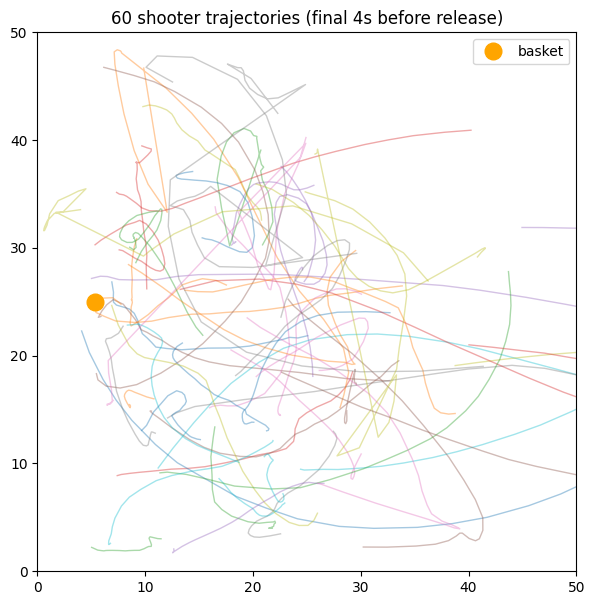

In [3]:
fig, ax = plt.subplots(figsize=(7,7))
for (_, _), g in list(t.groupby(['GAME_ID','GAME_EVENT_ID']))[:60]:
    ax.plot(g.x, g.y, alpha=0.4, lw=1)
ax.plot(5.35, 25, 'o', color='orange', ms=12, label='basket')
ax.set_xlim(0,50); ax.set_ylim(0,50); ax.set_aspect('equal')
ax.set_title('60 shooter trajectories (final 4s before release)')
ax.legend(); plt.show()

**Acceptance:** at least 50 aligned shot-ending trajectories.

In [4]:
assert n_traj >= 50, n_traj